# 1. Install Dependencies and Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/Cheating_enhancement/


/content/drive/MyDrive/Cheating_enhancement


In [4]:
!pwd

/content/drive/MyDrive/Cheating_enhancement


In [12]:
import tensorflow as tf
import os

# 2. Remove dodgy images

In [5]:
import cv2
import imghdr

In [6]:
data_dir = "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep"

In [7]:
image_exts = ['jpeg','jpg', 'bmp', 'png']

In [13]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))
            # os.remove(image_path)

# 3. Load Data

In [14]:
import numpy as np
from matplotlib import pyplot as plt

In [15]:
data_dir = "/content/drive/MyDrive/Cheating_enhancement/data/data1_oep"
data = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(224, 224),
    batch_size=32  # you can adjust batch size as desired
)


Found 11581 files belonging to 2 classes.


In [16]:
data_iterator = data.as_numpy_iterator()

In [17]:
batch = data_iterator.next()

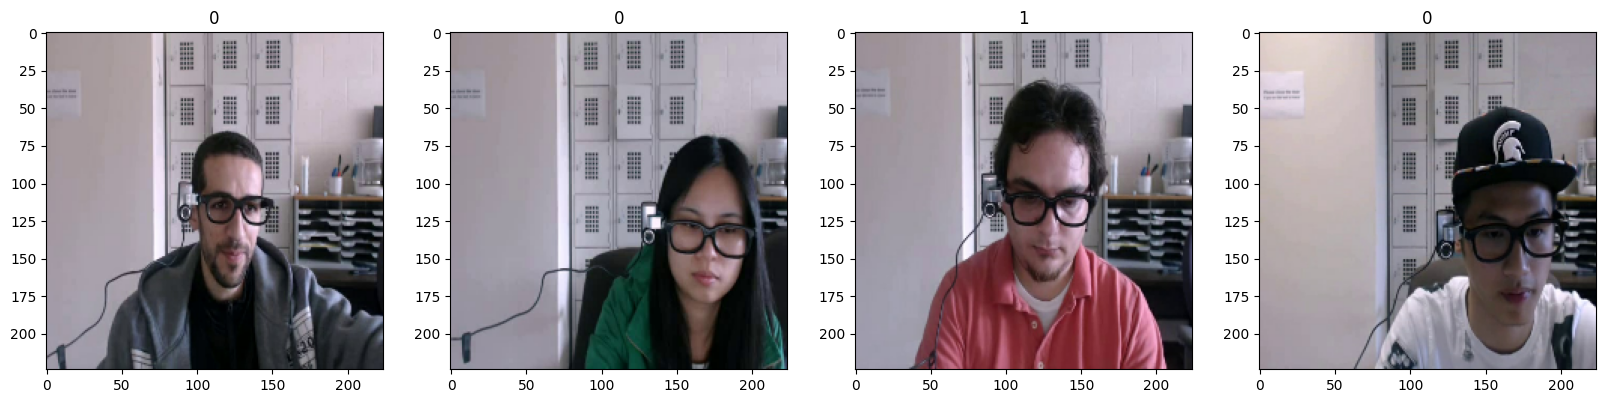

In [18]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

# 4. Scale Data

In [19]:
data = data.map(lambda x,y: (x/255, y))

In [20]:
data.as_numpy_iterator().next()

(array([[[[0.6156863 , 0.5686275 , 0.58431375],
          [0.6156863 , 0.5686275 , 0.58431375],
          [0.6156863 , 0.5686275 , 0.58431375],
          ...,
          [0.80784315, 0.7764706 , 0.8352941 ],
          [0.80784315, 0.7764706 , 0.8352941 ],
          [0.80784315, 0.7764706 , 0.8352941 ]],
 
         [[0.6156863 , 0.5686275 , 0.58431375],
          [0.6156863 , 0.5686275 , 0.58431375],
          [0.6156863 , 0.5686275 , 0.58431375],
          ...,
          [0.80784315, 0.7764706 , 0.8352941 ],
          [0.80784315, 0.7764706 , 0.8352941 ],
          [0.80784315, 0.7764706 , 0.8352941 ]],
 
         [[0.6156863 , 0.5686275 , 0.58431375],
          [0.6156863 , 0.5686275 , 0.58431375],
          [0.6156863 , 0.5686275 , 0.58431375],
          ...,
          [0.80784315, 0.7764706 , 0.8352941 ],
          [0.80784315, 0.7764706 , 0.8352941 ],
          [0.80784315, 0.7764706 , 0.8352941 ]],
 
         ...,
 
         [[0.61960787, 0.60784316, 0.6745098 ],
          [0.61960

# 5. Split Data

In [21]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [22]:
train_size

253

In [23]:
test_size

36

In [24]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [28]:
test2 = data.take(30)

# 6. Build Deep Learning Model

In [31]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [33]:
model = Sequential()

In [34]:
model.add(Conv2D(32,kernel_size=(2,2),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(2,2),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128,(2,2),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(256,(2,2),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.1))

model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.compile(optimizer= tf.keras.optimizers.RMSprop(), loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 223, 223, 32)        │             416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 110, 110, 64)        │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 55, 55, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 54, 54, 128)         │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 27, 27, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 26, 26, 256)         │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 13, 13, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 43264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      22,151,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,325,089 (85.16 MB)

 Trainable params: 22,325,089 (85.16 MB)

 Non-trainable params: 0 (0.00 B)

# 7. Train

In [ ]:
logdir='logs'

In [ ]:
import time
t1=time.time()
hist = model.fit(train, epochs=60, validation_data=val)
t2= time.time()
temps_execution = t2 - t1
print(f"Le temps d'exécution est de {temps_execution} secondes.")

Epoch 1/60
253/253 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.9259 - loss: 0.1904 - val_accuracy: 0.9049 - val_loss: 0.2907
Epoch 2/60
253/253 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.9371 - loss: 0.1626 - val_accuracy: 0.9002 - val_loss: 0.3954
Epoch 3/60
253/253 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.9434 - loss: 0.1545 - val_accuracy: 0.9054 - val_loss: 0.3389
Epoch 4/60
253/253 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.9500 - loss: 0.1258 - val_accuracy: 0.9171 - val_loss: 0.3045
Epoch 5/60
253/253 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.9641 - loss: 0.1003 - val_accuracy: 0.9123 - val_loss: 0.2851
Epoch 6/60
253/253 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.9696 - loss: 0.0913 - val_accuracy: 0.9093 - val_loss: 0.4092
Epoch 7/60
253/253 ━━━━━━━━━━━━━━━━━━━━ 26s 101ms/step - accuracy: 0.9672 - loss: 0.0941 - val_accuracy: 0.9175 - val_loss: 0.3494
Epoch 8/60
253/253 ━━━━━━━━━━━━━━━━━━━━ 26s 102ms/step - accuracy: 0.9747 - loss: 0.080

# 8. Plot Performance

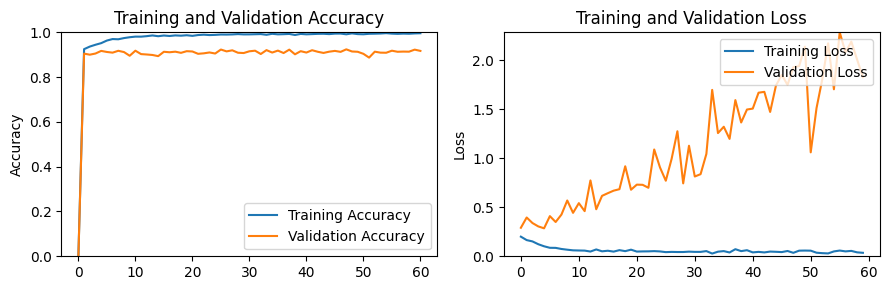

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'history' contains your training history

acc = [0.] + hist.history['accuracy']
val_acc = [0.] + hist.history['val_accuracy']

loss = hist.history['loss']
val_loss = hist.history['val_loss']

# Create a figure with two subplots in the same row
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

# Plot accuracy
ax1.plot(acc, label='Training Accuracy')
ax1.plot(val_acc, label='Validation Accuracy')
ax1.legend(loc='lower right')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training and Validation Accuracy')

# Plot loss
ax2.plot(loss, label='Training Loss')
ax2.plot(val_loss, label='Validation Loss')
ax2.legend(loc='upper right')
ax2.set_ylabel('Loss')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training and Validation Loss')

plt.tight_layout()
plt.show()

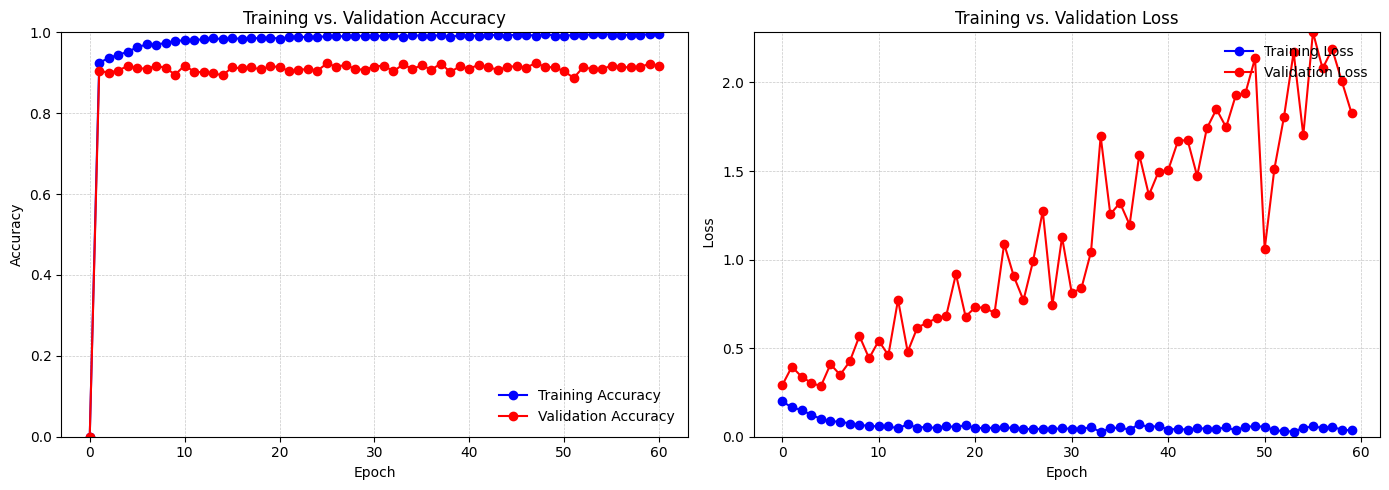

In [ ]:
import matplotlib.pyplot as plt

# Sample Data (replace with your actual history data)
acc = [0.] + hist.history['accuracy']
val_acc = [0.] + hist.history['val_accuracy']
loss = hist.history['loss']
val_loss = hist.history['val_loss']

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training and Validation Accuracy Plot
ax1.plot(acc, marker='o', linestyle='-', color='blue', label='Training Accuracy')
ax1.plot(val_acc, marker='o', linestyle='-', color='red', label='Validation Accuracy')
ax1.legend(loc='lower right', fontsize=10, frameon=False)  # Legend inside the plot, lower right
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_ylim([min(min(acc), min(val_acc)), 1])
ax1.set_title('Training vs. Validation Accuracy')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Training and Validation Loss Plot
ax2.plot(loss, marker='o', linestyle='-', color='blue', label='Training Loss')
ax2.plot(val_loss, marker='o', linestyle='-', color='red', label='Validation Loss')
ax2.legend(loc='upper right', fontsize=10, frameon=False)  # Legend inside the plot, upper right
ax2.set_xlabel('Epoch')
ax2.set_ylabel(' Loss')
ax2.set_ylim([0, max(max(loss), max(val_loss))])
ax2.set_title('Training vs. Validation Loss')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)  # Light grid lines

# Adjust layout and background color
fig.patch.set_facecolor('white')  # Set figure background to white
fig.tight_layout(rect=[0, 0, 1, 1])  # Adjust layout to fit everything nicely
plt.show()


# 9. Evaluate

In [ ]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [ ]:
# Evaluate the model on the training dataset
train_loss, *train_metrics = model.evaluate(train)
print("Training Loss:", train_loss)
print("Training Metrics:", train_metrics)

# Evaluate the model on the validation dataset
val_loss, *val_metrics = model.evaluate(val)
print("Validation Loss:", val_loss)
print("Validation Metrics:", val_metrics)

253/253 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9990 - loss: 0.0043
Training Loss: 0.008408998139202595
Training Metrics: [0.9982707500457764]
72/72 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.9291 - loss: 1.5899
Validation Loss: 1.8692220449447632
Validation Metrics: [0.9166666865348816]


In [ ]:
import time

# Start the timer
t3 = time.time()

# Evaluate the model on the test dataset
test_loss, *test_metrics = model.evaluate(test)

# End the timer
t4 = time.time()

# Calculate and print the execution time
temps_execution = t4 - t3
print(f"Le temps d'exécution est de {temps_execution} secondes.")

# Print the test loss and metrics
print("Test Loss:", test_loss)
print("Test Metrics:", test_metrics)


36/36 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.9292 - loss: 1.5320
Le temps d'exécution est de 15.393441915512085 secondes.
Test Loss: 1.6971298456192017
Test Metrics: [0.9149305820465088]


In [ ]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [ ]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y, yhat)
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

In [ ]:
print(pre.result(), re.result(), acc.result())

tf.Tensor(0.8974943, shape=(), dtype=float32) tf.Tensor(0.88539326, shape=(), dtype=float32) tf.Tensor(0.9166667, shape=(), dtype=float32)


In [ ]:
y_pred = []  # store predicted labels
y_true = []  # store true labels
y_pred1 = []
# iterate over the dataset
for image_batch, label_batch in test:   # use dataset.unbatch() with repeat
   # append true labels
   y_true.append(label_batch)
   # compute predictions
   preds= model.predict(image_batch)
   # append predicted labels
   # y_pred.append(np.argmax(preds, axis = - 1))
   #y_pred.append( preds.argmax(axis = 1))
   #y_pred=rech(preds)
   y_pred=np.where(preds> 0.5, 1,0)
   y_pred1.append(y_pred)
# convert the true and predicted labels into tensors
yr= tf.concat([item for item in y_true], axis = 0)
yp = tf.concat([item for item in y_pred1], axis = 0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━

In [ ]:
#yr

In [ ]:
#yp

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
report = classification_report(yr,yp)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.93      0.92       705
           1       0.89      0.86      0.88       447

    accuracy                           0.91      1152
   macro avg       0.90      0.90      0.90      1152
weighted avg       0.91      0.91      0.91      1152



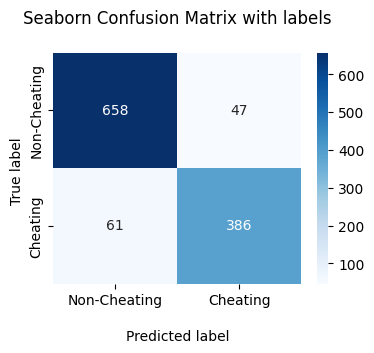

In [ ]:
from sklearn.metrics import confusion_matrix
# importing library for plotting
import matplotlib.pyplot as plt
# plot the confusion matrix
f,ax = plt.subplots(figsize=(4,3))
#Generate the confusion matrix
cf_matrix = confusion_matrix(yr, yp)
import seaborn as sns

ax = sns.heatmap(cf_matrix, annot=True, cmap=plt.cm.Blues, fmt='g')

ax.set_title('Seaborn Confusion Matrix with labels\n');
ax.set_xlabel('\nPredicted label')
ax.set_ylabel('True label ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['Non-Cheating','Cheating'])
ax.yaxis.set_ticklabels(['Non-Cheating','Cheating'])

## Display the visualization of the Confusion Matrix.
plt.show()

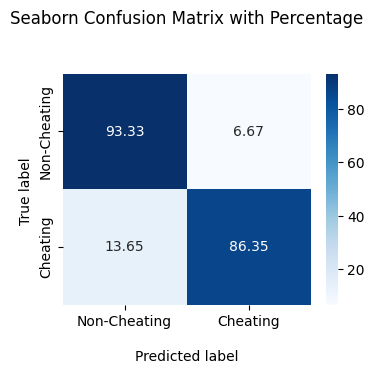

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
f,ax = plt.subplots(figsize=(4,3))
# Generate the confusion matrix
cf_matrix = confusion_matrix(yr, yp)

# Calculate the percentages
cf_matrix_percent = cf_matrix / cf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Create the heatmap
ax = sns.heatmap(cf_matrix_percent, annot=True, cmap=plt.cm.Blues, fmt='.2f')

# Set the title and labels
ax.set_title('Seaborn Confusion Matrix with Percentage\n\n')
ax.set_xlabel('\nPredicted label')
ax.set_ylabel('True label ')

# Set tick labels
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'])
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'])

# Display the visualization of the Confusion Matrix with percentage
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

print('f1_score=',f1_score(yr, yp, average='macro'))

f1_score= 0.9007150153217569


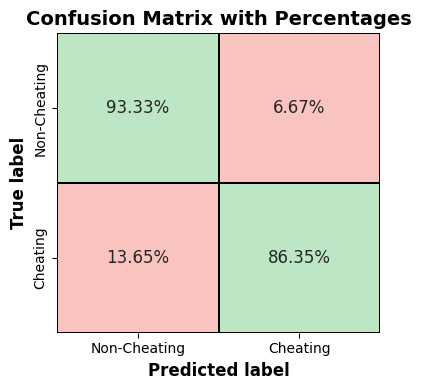

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness
conf_matrix = confusion_matrix(yr, yp)
# Calculate the percentages
cf_matrix_percent = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis] * 100

# Create the labels with percentages
labels = [f'{value:.2f}%' for value in cf_matrix_percent.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_percent, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels (matching appearance from the previous code)
ax.set_title('Confusion Matrix with Percentages', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


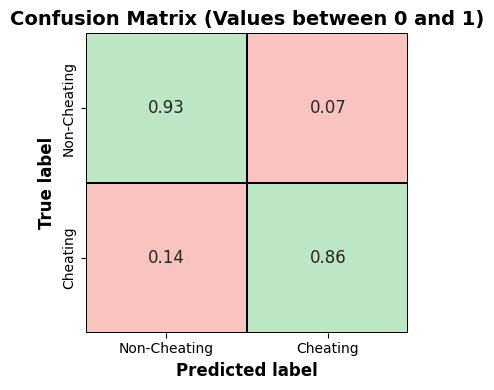

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate values between 0 and 1
cf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create labels showing values between 0 and 1
labels = [f'{value:.2f}' for value in cf_matrix_normalized.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels
ax.set_title('Confusion Matrix (Values between 0 and 1)', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


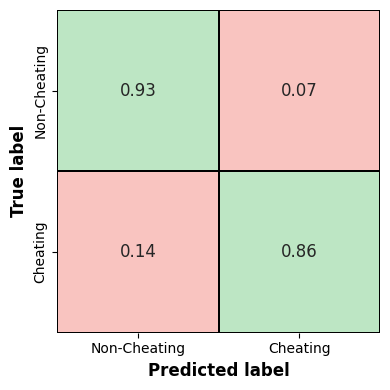

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming conf_matrix is defined elsewhere in your code
f, ax = plt.subplots(figsize=(4, 4))  # Adjust the figure size to be 4x4 for compactness

# Calculate values between 0 and 1
cf_matrix_normalized = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

# Create labels showing values between 0 and 1
labels = [f'{value:.2f}' for value in cf_matrix_normalized.flatten()]
labels = np.asarray(labels).reshape(conf_matrix.shape)

# Define a custom color map for the background
colors = ['#BDE6C4', '#F9C4C0']

# Use the same color palette as before
cmap = sns.color_palette(colors)

# Create a mask to differentiate True Positives/Negatives and False Positives/Negatives
mask = np.array([[True, False], [False, True]])  # Mask for the red areas (False values will be colored green)

# Create the heatmap with the custom background colors
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#F9C4C0']), mask=mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Overlay the original confusion matrix with a separate color (green) for TP and TN
sns.heatmap(cf_matrix_normalized, annot=labels, fmt='', cbar=False, cmap=sns.color_palette(['#BDE6C4']), mask=~mask,
            ax=ax, linewidths=1.2, linecolor='black', annot_kws={"size": 12})

# Set the title and labels
#ax.set_title('Confusion Matrix (Values between 0 and 1)', fontsize=14, weight='bold')
ax.set_xlabel('Predicted label', fontsize=12, weight='bold')
ax.set_ylabel('True label', fontsize=12, weight='bold')

# Set tick labels with smaller font sizes
ax.xaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)
ax.yaxis.set_ticklabels(['Non-Cheating', 'Cheating'], fontsize=10)

# Ensure everything fits well
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming y_true and y_pred are already defined

# Calculate accuracy, precision, recall, and f1 score
accuracy = accuracy_score(yr, yp)
precision = precision_score(yr, yp, average='binary')  # Use 'binary' for binary classification, or 'macro', 'micro' for multi-class
recall = recall_score(yr, yp, average='binary')
f1 = f1_score(yr, yp, average='binary')

# Print the results
print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Accuracy: 0.91
Precision: 0.89
Recall: 0.86
F1 Score: 0.88


AUC for our classifier is: 0.90


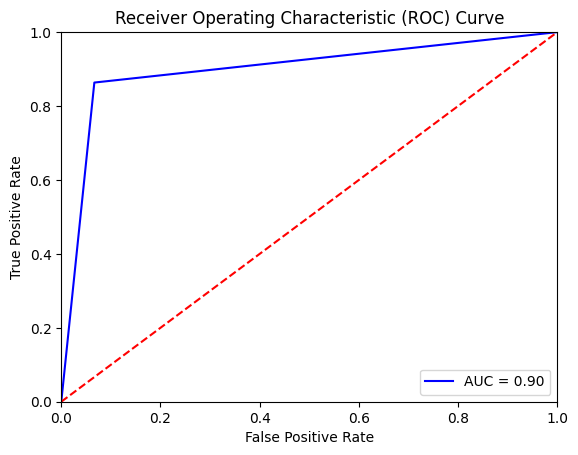

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
# ROC Curve
fpr, tpr, threshold = roc_curve(yr, yp)
roc_auc = auc(fpr, tpr)

# Printing AUC
print(f"AUC for our classifier is: {roc_auc:.2f}")

# Plotting the ROC curve
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.plot(fpr, tpr, 'b', label=f'AUC = {roc_auc:.2f}')
plt.legend(loc='lower right')
plt.plot([0, 1], [0, 1], 'r--')  # Diagonal line
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# 10. Test

In [ ]:
import cv2

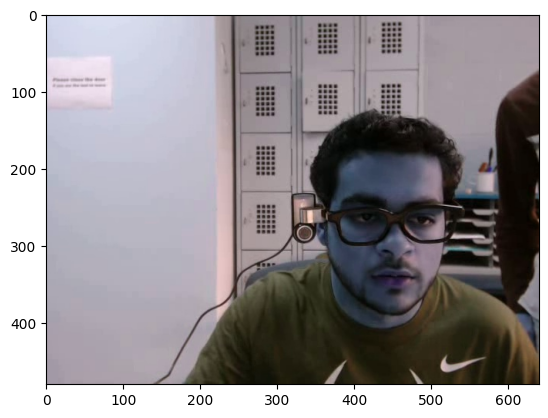

In [ ]:
img = cv2.imread('/content/drive/MyDrive/Cheating_enhancement/data/data1_oep/2.cheating/alhashe31frame450.jpg')
plt.imshow(img)
plt.show()


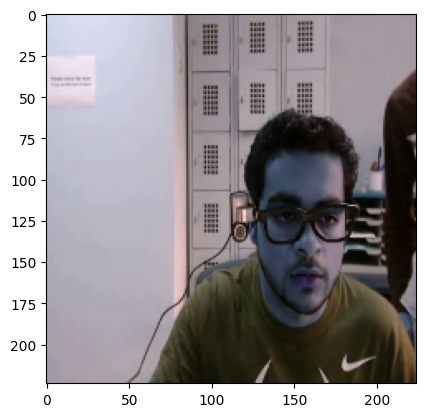

In [ ]:
resize = tf.image.resize(img, (224,224))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [ ]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step


In [ ]:
yhat

array([[0.8264773]], dtype=float32)

In [ ]:
if yhat > 0.5:
    print(f'Predicted class is cheating')
else:
    print(f'Predicted class is no cheating')

Predicted class is cheating


# 11. Save the Model

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
%cd /content/drive/MyDrive/Cheating_enhancement/
# Saving the model in HDF5 format
model_save_path = 'saved_models/cnn_d1.h5'
model.save(model_save_path)

/content/drive/MyDrive/Cheating_enhancement


In [ ]:
new_model = load_model('/content/drive/MyDrive/Cheating_enhancement/saved_models/cnn_d1.h5')

In [ ]:
new_model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


array([[0.8264773]], dtype=float32)

In [ ]:
import tensorflow as tf
%cd /content/drive/MyDrive/Cheating_enhancement/
# Specify the path to the saved model directory
model_path = 'saved_models/cnn_d1.h5'

# Load the trained model
model = tf.keras.models.load_model(model_path)

# The model is ready to use in inference mode


/content/drive/MyDrive/Cheating_enhancement


In [ ]:
import time

# Initialize variables to accumulate time and count images
total_time = 0
num_images = 0

# Loop over the dataset to measure time for each image
for images, labels in test:
    start_time = time.time()
    _ = model.evaluate(images, labels, verbose=0)  # Evaluate on a single batch (1 image at a time if batch size is 1)
    end_time = time.time()

    # Accumulate time and count
    total_time += (end_time - start_time)
    num_images += images.shape[0]  # Add number of images in the batch
print(total_time )
print(f"test time: {total_time:.4f} seconds")
print('---------------------')
print( num_images)
print('---------------------')
# Calculate average time per image
average_time_per_image = total_time / num_images
print(f"Average time per image: {average_time_per_image:.4f} seconds")


5.089554309844971
test time: 5.0896 seconds
---------------------
1152
---------------------
Average time per image: 0.0044 seconds


In [ ]:
import time

# Assuming `model` is your loaded model
# Start timing
start_time = time.time()

# Run the model on the entire test dataset to get predictions
predictions = model.predict(test)

# End timing
end_time = time.time()

# Calculate total and average time
total_time = end_time - start_time
num_images = sum(batch.shape[0] for batch, _ in test)  # Total number of images

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per image: {total_time / num_images:.4f} seconds")


36/36 ━━━━━━━━━━━━━━━━━━━━ 341s 841ms/step
Total inference time: 341.7623 seconds
Average time per image: 0.2967 seconds


In [37]:
import time

# Assuming `model` is your loaded model
# Start timing
start_time = time.time()

# Run the model on the entire test dataset to get predictions
predictions = model.predict(test2)

# End timing
end_time = time.time()

# Calculate total and average time
total_time = end_time - start_time
num_images = sum(batch.shape[0] for batch, _ in test)  # Total number of images

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per image: {total_time / num_images:.4f} seconds")


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Total inference time: 1.4755 seconds
Average time per image: 0.0013 seconds
